<h1 align="center">Deep Learning Models for Promoter Prediction</h1>
<h2 align="center">Evaluating CNNs and Transformers on Genomic Sequences</h2>
<h3 align="center">Exploratory Data Analysis</h3>

<div style="margin-bottom: 50px;"></div>
<div style="display: flex; justify-content: center;">
    <table style="border-collapse: collapse; border: 0;">
        <tr>
            <td style="text-align:center; vertical-align:middle; padding:10px 40px 10px 10px; border: 0;">
                <h3 style="margin: 0;">Radek Holik</h3>
                April 2026
            </td>
        </tr>
    </table>
</div>
<br>



### Description
This notebook explores genomic and promoter sequence data, including sequence characteristics, base composition, and data quality. The goal is to understand the structure of the data before preprocessing and model development.


### Imports and paths

In [1]:
from pathlib import Path        # handle file paths in a cross-platform way
import os                       # interact with operating system (files, directories)
from collections import Counter # count occurrences (e.g., nucleotides, k-mers)

import pandas as pd             # data manipulation and analysis
import matplotlib.pyplot as plt # plotting
import seaborn as sns           # statistical data visualization (built on matplotlib)

In [2]:
# Paths
project_root = Path("..").resolve()          # project root directory
data_dir = project_root / "data"             # main data folder
raw_dir = data_dir / "raw"                   # raw data folder
genome_dir = raw_dir / "genome"              # genome data folder
uci_dir = raw_dir / "uci_promoter"           # UCI dataset folder

fa_path = genome_dir / "chr1.fa"             # chromosome 1 FASTA file

def rel(path):
    return Path(os.path.relpath(path, project_root))  # convert to relative path

print("Project root:")
print("Genome file:", rel(fa_path).as_posix())  # display genome file path
print("UCI folder:", rel(uci_dir).as_posix())   # display UCI dataset path

Project root:
Genome file: data/raw/genome/chr1.fa
UCI folder: data/raw/uci_promoter


### Load FASTA File

In [3]:
def read_fasta(file_path):
    with open(file_path, "r") as f:
        header = f.readline().strip()                   # read FASTA header line
        sequence = "".join(line.strip() for line in f)  # concatenate sequence lines
    return header, sequence

header, sequence = read_fasta(fa_path)

print("Genome loaded.")
print("Header:")
print(header)
print()
print(f"Total sequence length: {len(sequence):,} bases")  # report sequence size

Genome loaded.
Header:
>1 dna:chromosome chromosome:GRCh38:1:1:248956422:1 REF

Total sequence length: 248,956,422 bases


### Basic Genome Quality Checks

In [4]:
# Find first valid DNA base (skip leading Ns)
first_real_idx = next((i for i, base in enumerate(sequence) if base in {"A", "C", "G", "T"}), None)

# Extract usable sequence starting from first real base
usable_sequence = sequence[first_real_idx:]

print(f"First real DNA base position: {first_real_idx:,}")
print()

print("First 100 bases of raw sequence:")
print(sequence[:100])  # preview raw sequence (may include Ns)
print()

print("First 100 real DNA bases:")
print(sequence[first_real_idx:first_real_idx + 100])  # preview cleaned start
print()

print(f"Usable sequence length: {len(usable_sequence):,}")  # length after trimming

First real DNA base position: 10,000

First 100 bases of raw sequence:
NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN

First 100 real DNA bases:
TAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAAC

Usable sequence length: 248,946,422


### Count and Percentage Calculations

In [5]:
# Count nucleotide occurrences in usable sequence
usable_base_counts = Counter(usable_sequence)

usable_length = len(usable_sequence)  # total length of usable sequence

print("Usable base counts and percentages:")
for base in ["A", "C", "G", "T", "N"]:
    count = usable_base_counts.get(base, 0)          # count for each base
    pct = (count / usable_length) * 100              # percentage of total
    print(f"{base}: {count:,} ({pct:.2f}%)")

Usable base counts and percentages:
A: 67,070,277 (26.94%)
C: 48,055,043 (19.30%)
G: 48,111,528 (19.33%)
T: 67,244,164 (27.01%)
N: 18,465,410 (7.42%)


### Visualize Base Composition

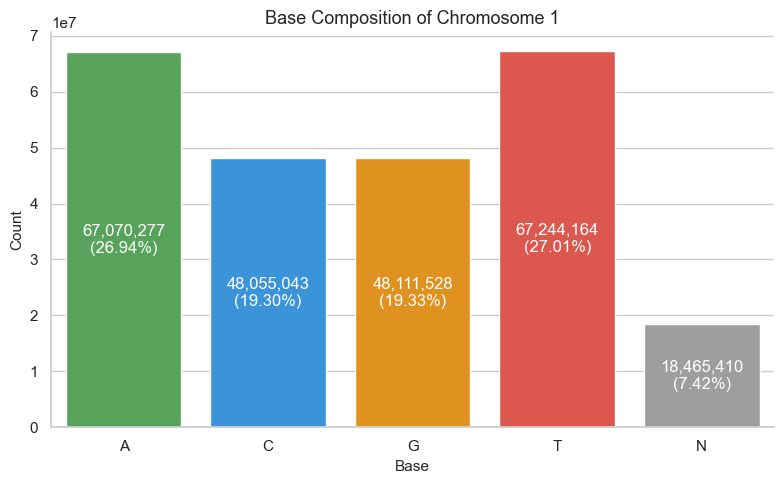

In [ ]:
sns.set_theme(style="whitegrid")  # clean background with light grid

bases = ["A", "C", "G", "T", "N"]
counts = [usable_base_counts.get(base, 0) for base in bases]

total = sum(counts)
percentages = [(c / total) * 100 for c in counts]

# Create DataFrame
df = pd.DataFrame({
    "Base": bases,
    "Count": counts,
    "Percentage": percentages
})

plt.figure(figsize=(8, 5))

sns.set_theme(style="whitegrid")

palette = {
    "A": "#4CAF50",
    "C": "#2196F3",
    "G": "#FF9800",
    "T": "#F44336",
    "N": "#9E9E9E"
}

ax = sns.barplot(
    data=df,
    x="Base",
    y="Count",
    hue="Base",          # assign hue
    palette=palette,
    legend=False         # avoid duplicate legend
)

plt.title("Base Composition of Chromosome 1", fontsize=13)
plt.xlabel("Base", fontsize=11)
plt.ylabel("Count", fontsize=11)

# Add labels inside bars
for i, row in df.iterrows():
    ax.text(
        i,
        row["Count"] * 0.5,
        f"{int(row['Count']):,}\n({row['Percentage']:.2f}%)",
        ha="center",
        va="center",
        color="white",
        fontsize=12
    )

# Clean up spines
sns.despine()

plt.tight_layout()
plt.show()

### GC Content Analysis

GC content refers to the proportion of guanine (G) and cytosine (C) bases in a DNA sequence. It is an important genomic characteristic that influences DNA stability, gene regulation, and sequencing properties.

In this section, we compute the GC content of the usable chromosome 1 sequence to assess whether it aligns with known properties of the human genome.

In [ ]:
# Compute GC count and percentage
gc = usable_base_counts["G"] + usable_base_counts["C"]  # total G and C bases
gc_pct = (gc / len(usable_sequence)) * 100              # GC percentage

print(f"GC content: {gc_pct:.2f}%")  # display result

GC content: 38.63%


#### Interpretation

The computed GC content of approximately 38.6% is consistent with known characteristics of the human genome, which typically exhibits a GC content in the range of 38–41%. 

This confirms that the extracted chromosome 1 sequence is biologically representative and suitable for downstream analysis and modeling.

### Base Composition along Genome

In [ ]:
def sliding_gc(sequence, window=50_000, step=5_000):
    gc_values = []   # store GC percentages
    positions = []   # store window start positions

    # Slide window across sequence
    for i in range(0, len(sequence) - window, step):
        segment = sequence[i:i+window]            # extract window segment
        gc = segment.count("G") + segment.count("C")  # count G and C bases
        gc_pct = gc / window * 100                # compute GC percentage

        gc_values.append(gc_pct)
        positions.append(i)

    return positions, gc_values  # return positions and GC values

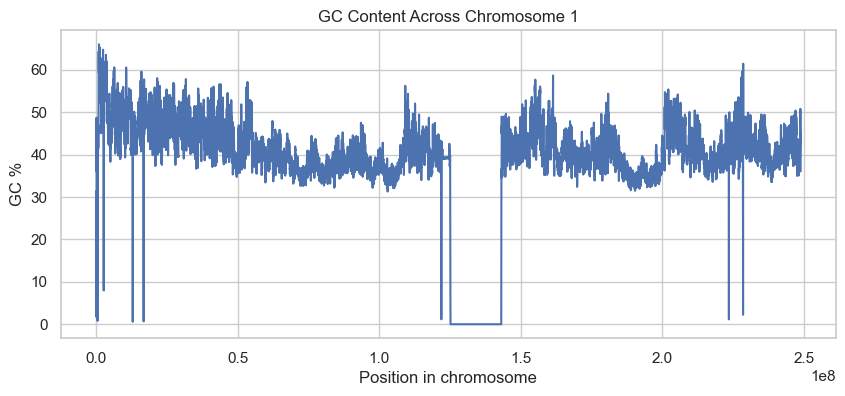

In [ ]:
# Compute GC content across sequence using sliding window
positions, gc_values = sliding_gc(usable_sequence)

plt.figure(figsize=(10, 4))          # set figure size
plt.plot(positions, gc_values)       # plot GC percentage vs position
plt.xlabel("Position in chromosome")
plt.ylabel("GC %")
plt.title("GC Content Across Chromosome 1")

plt.show()                           # display plot

A prominent region with near-zero GC content is observed, corresponding to a large contiguous segment dominated by ambiguous bases (N). This indicates an unresolved or low-confidence region in the reference genome rather than a true biological signal.

### K-mer Frequency Analysis

K-mers represent short contiguous nucleotide patterns within DNA sequences.  
Analyzing their frequency provides insight into local sequence structure and compositional biases.

Here, we visualize the most frequent k-mers in the usable chromosome 1 sequence.

In [ ]:
def count_kmers(sequence, k=2, valid_bases={"A", "C", "G", "T"}):
    kmers = []  # store valid k-mers

    # Extract k-mers from sequence
    for i in range(len(sequence) - k + 1):
        kmer = sequence[i:i+k]                       # current k-mer
        if set(kmer).issubset(valid_bases):          # filter valid bases only
            kmers.append(kmer)

    return Counter(kmers)  # return k-mer frequency counts

In [ ]:
def summarize_kmers(sequence, k=2, top_n=10):
    kmer_counts = count_kmers(sequence, k=k)  # compute k-mer frequencies
    total_kmers = sum(kmer_counts.values())   # total number of k-mers

    print(f"Number of unique {k}-mers: {len(kmer_counts)}")
    print(f"Total {k}-mers counted: {total_kmers:,}")
    print()
    print(f"Top {top_n} most common {k}-mers:")

    # Display top k-mers with percentages
    for kmer, count in kmer_counts.most_common(top_n):
        pct = (count / total_kmers) * 100
        print(f"{kmer}: {count:,} ({pct:.2f}%)")

    return kmer_counts, total_kmers  # return counts and total

In [ ]:
def plot_kmers(kmer_counts, k=2, top_n=20):

    # Create DataFrame and sort by frequency
    df_kmer = pd.DataFrame(
        kmer_counts.items(),
        columns=["kmer", "Count"]
    ).sort_values("Count", ascending=False)

    total = df_kmer["Count"].sum()                         # total k-mer count
    df_kmer["Percentage"] = df_kmer["Count"] / total * 100 # compute percentages

    df_kmer = df_kmer.head(top_n)  # keep top k-mers for readability

    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=df_kmer, x="kmer", y="Count")  # plot frequencies

    plt.title(f"Top {top_n} {k}-mer Frequencies")
    plt.xlabel(f"{k}-mer")
    plt.ylabel("Count")

    plt.xticks(rotation=45)  # improve label readability
    plt.tight_layout()
    plt.show()

    return df_kmer  # return DataFrame for further use

#### 2-mer

Number of unique 2-mers: 16
Total 2-mers counted: 230,480,845

Top 10 most common 2-mers:
TT: 22,048,241 (9.57%)
AA: 21,901,540 (9.50%)
AT: 17,121,783 (7.43%)
TG: 16,796,378 (7.29%)
CA: 16,768,284 (7.28%)
AG: 16,448,644 (7.14%)
CT: 16,444,797 (7.13%)
TA: 14,554,789 (6.31%)
GA: 13,845,615 (6.01%)
TC: 13,844,699 (6.01%)


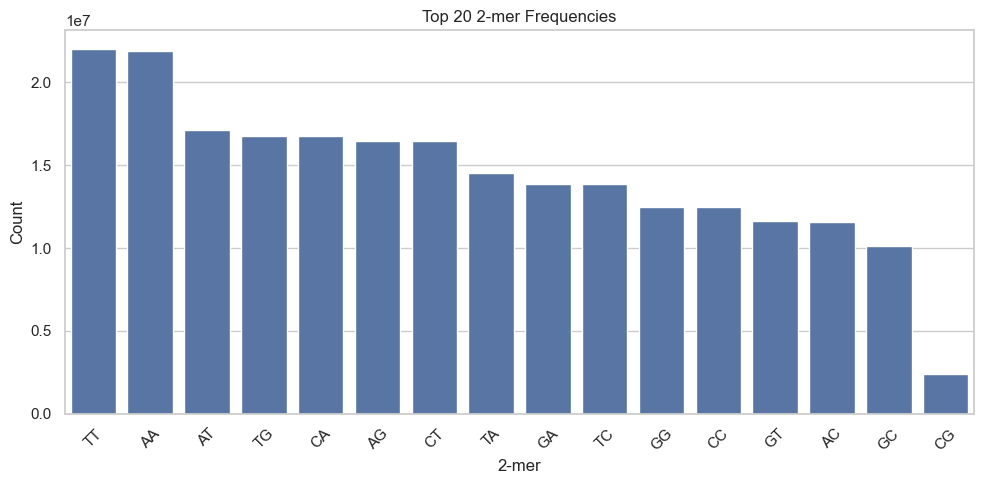

In [13]:
k = 2

kmer_counts, total_kmers = summarize_kmers(usable_sequence, k=k)

df_kmer = plot_kmers(kmer_counts, k=k)

#### 3-mer

In [14]:
k = 3

kmer_counts, total_kmers = summarize_kmers(usable_sequence, k=k)

df_kmer = plot_kmers(kmer_counts, k=k)

KeyboardInterrupt: 

#### 4-mer

Number of unique 4-mers: 256
Total 4-mers counted: 230,480,526

Top 10 most common 4-mers:
TTTT: 3,449,146 (1.50%)
AAAA: 3,424,458 (1.49%)
ATTT: 2,205,061 (0.96%)
AAAT: 2,185,836 (0.95%)
TTTA: 1,792,472 (0.78%)
TAAA: 1,789,483 (0.78%)
AGAA: 1,786,105 (0.77%)
TTCT: 1,785,019 (0.77%)
GAAA: 1,689,032 (0.73%)
TTTC: 1,681,590 (0.73%)


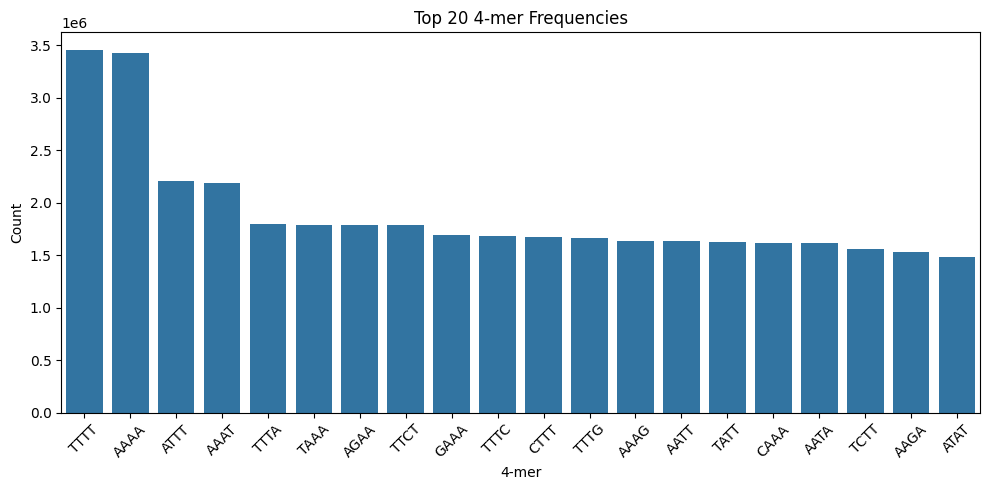

In [ ]:
k = 4

kmer_counts, total_kmers = summarize_kmers(usable_sequence, k=k)

df_kmer = plot_kmers(kmer_counts, k=k)

#### 5-mer

Number of unique 5-mers: 1024
Total 5-mers counted: 230,480,370

Top 10 most common 5-mers:
TTTTT: 1,526,551 (0.66%)
AAAAA: 1,513,743 (0.66%)
ATTTT: 875,970 (0.38%)
AAAAT: 874,814 (0.38%)
AAATA: 729,010 (0.32%)
TATTT: 725,597 (0.31%)
TAAAA: 724,087 (0.31%)
TTTTA: 720,955 (0.31%)
TTTCT: 713,282 (0.31%)
AGAAA: 713,000 (0.31%)


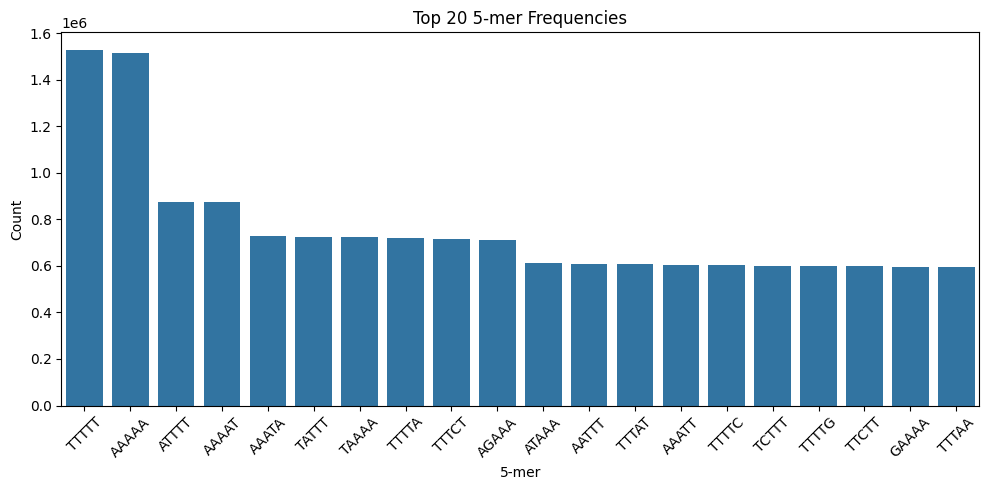

In [ ]:
k = 5

kmer_counts, total_kmers = summarize_kmers(usable_sequence, k=k)

df_kmer = plot_kmers(kmer_counts, k=k)

#### 6-mer

Number of unique 6-mers: 4096
Total 6-mers counted: 230,480,216

Top 10 most common 6-mers:
TTTTTT: 791,351 (0.34%)
AAAAAA: 785,968 (0.34%)
ATTTTT: 353,749 (0.15%)
AAAAAT: 353,291 (0.15%)
TATTTT: 310,032 (0.13%)
AAAATA: 308,853 (0.13%)
TAAAAA: 287,391 (0.12%)
TTTTTA: 285,496 (0.12%)
TTTCTT: 273,569 (0.12%)
AGAAAA: 272,666 (0.12%)


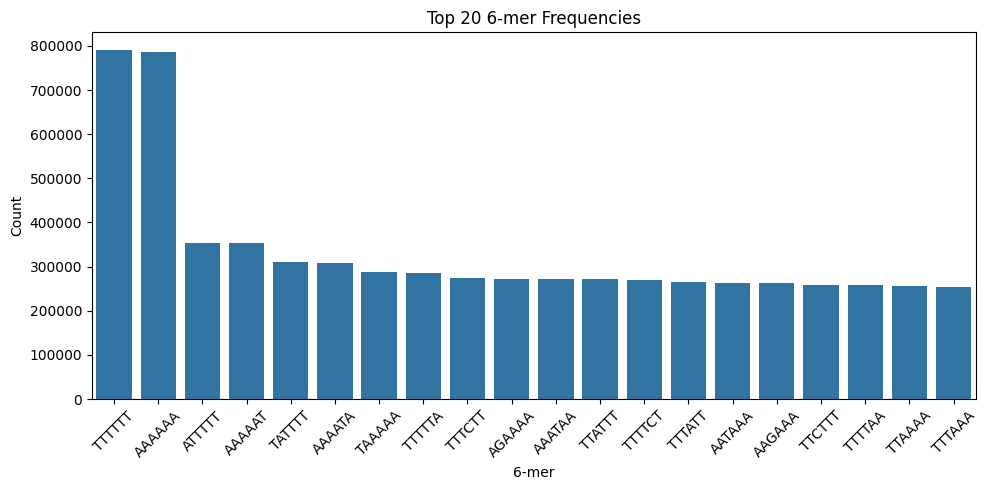

In [ ]:
k = 6

kmer_counts, total_kmers = summarize_kmers(usable_sequence, k=k)

df_kmer = plot_kmers(kmer_counts, k=k)

### N Distribution

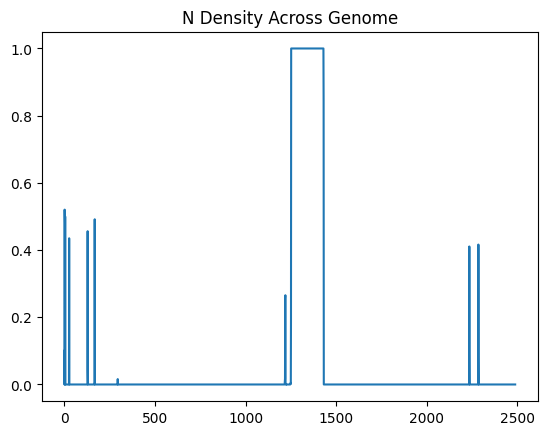

In [ ]:
window = 100_000
n_density = []  # store N density per window

# Compute N density across genome
for i in range(0, len(sequence) - window, window):
    segment = sequence[i:i+window]                # extract window segment
    n_density.append(segment.count("N") / window) # proportion of N bases

plt.plot(n_density)                               # plot N density
plt.title("N Density Across Genome")
plt.show()